<a href="https://colab.research.google.com/github/Piyush-Sharma-1/SI_Crystal_Generative_Model/blob/main/sampler_checks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ase -q
!pip install torch-geometric -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 9.4 MB/s eta 0:00:00:00:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 874.0 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.3 MB/s eta 0:00:0000:0100:01


In [ ]:
!pip install tqdm
from tqdm.auto import tqdm

[v4i3] using source at: /kaggle/input/datasets/phantomygyj/atomic-recipes/atomic-recipes-code/atomic-recipes-main
[v4i3] confirmed EquivariantDecoder present
device: cuda
[cache] building fresh clean graphs (iter3 graph.py in effect)
ep  1 | kl_w 0.0001 | kl 3535 | agg 385.8 | SCORE 7.102 | total 46.04
ep  2 | kl_w 0.0051 | kl 1006 | agg 4.974 | SCORE 1.059 | total 6.684
ep  3 | kl_w 0.0101 | kl 544 | agg 7.989 | SCORE 1.01 | total 7.298
ep  4 | kl_w 0.0151 | kl 413.2 | agg 8.047 | SCORE 1.003 | total 8.042
ep  5 | kl_w 0.0201 | kl 329.5 | agg 11.67 | SCORE 0.9947 | total 8.778
ep  6 | kl_w 0.0251 | kl 268.7 | agg 8.854 | SCORE 0.9902 | total 8.614
ep  7 | kl_w 0.0301 | kl 223.7 | agg 10.05 | SCORE 0.9971 | total 8.73
ep  8 | kl_w 0.0351 | kl 188.2 | agg 10.39 | SCORE 0.9853 | total 8.624
ep  9 | kl_w 0.0401 | kl 165.7 | agg 9.769 | SCORE 0.9784 | total 8.593
ep 10 | kl_w 0.0451 | kl 146.5 | agg 11.01 | SCORE 1.006 | total 8.71
ep 11 | kl_w 0.0501 | kl 123.9 | agg 12.03 | SCORE 0.99 | 

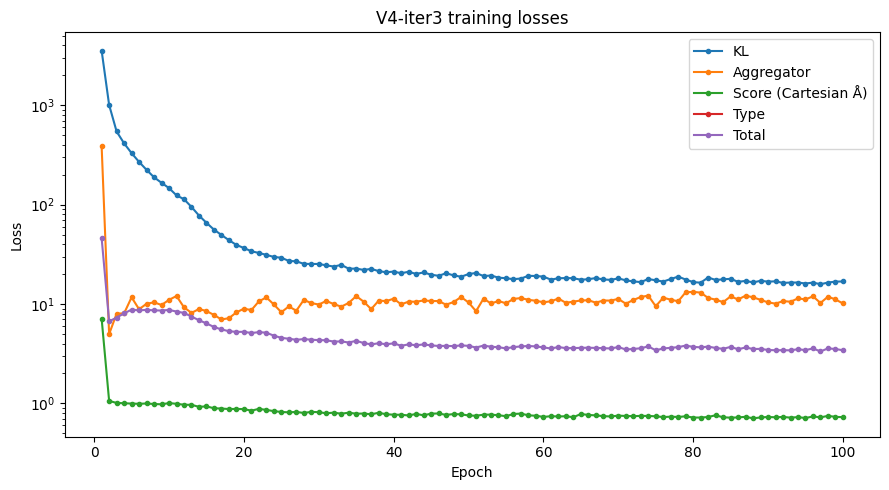

In [ ]:
#training script:

import sys, os, json, time, glob, itertools, importlib
from pathlib import Path

V4_ROOT = "/kaggle/input/datasets/phantomygyj/atomic-recipes/atomic-recipes-code/atomic-recipes-main"
assert Path(V4_ROOT).exists(), f"V4-iter3 not found at {V4_ROOT} — attach dataset"
print("[v4i3] using source at:", V4_ROOT)

for m in list(sys.modules):
    if m.startswith("atomic_recipes"):
        del sys.modules[m]
sys.path.insert(0, str(Path(V4_ROOT) / "src"))

import numpy as np, torch, pandas as pd
import torch.nn as nn, torch.nn.functional as F
from ase import io as ase_io, Atoms
import atomic_recipes.genml.vae as vae
importlib.reload(vae)
assert hasattr(vae, "EquivariantDecoder"), "Wrong vae (no EquivariantDecoder)"
print("[v4i3] confirmed EquivariantDecoder present")

from atomic_recipes.data.material import Material, MaterialsDataset
from atomic_recipes.data.graph import MaterialGraph, _niggli_to_reduced
from atomic_recipes.genml.vae import (
    GaussianPosteriorEncoder, Aggregator, LangevinDynamics,
    LossKLDivergenceGaussianPosterior, LossAggregator,
    EquivariantDecoder,
)
from atomic_recipes.regression.mpgnn import SimpleMessagePassingGNN
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.data import Batch
import matplotlib.pyplot as plt

POSCAR_500 = "/kaggle/input/datasets/phantomygyj/poscar-500"
CACHE_DIR  = Path("/kaggle/working/graph_cache_v4i3")
GEN_DIR    = "/kaggle/working/Generated_V4i3"
REF_PATH   = "/kaggle/input/datasets/phantomygyj/poscars/POSCARS25084/POSCAR_00001"
EPOCHS, BATCH, LR, HIDDEN, LATENT, N_LAYERS = 100, 16, 1e-3, 64, 32, 3
NOISE = {"sigma_start": 0.04, "sigma_end": 3}
W = {"kl": 1.0, "aggregator": 0.10, "score": 1.0, "type": 1.0}
N_SIGMAS, INNER_STEPS, EPSILON = 10, 100, 1e-5
CUTOFF, FLOOR, WIN = 6.0, 2.0, (2.0, 2.6)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
if not (CACHE_DIR / "manifest.json").exists():
    print("[cache] building fresh clean graphs (iter3 graph.py in effect)")
    files = sorted(p for p in Path(POSCAR_500).rglob("POSCAR*") if p.is_file())
    assert files
    mats = [Material(direct_positions=torch.tensor(s.get_scaled_positions()).float(),
                     atom_numbers=torch.tensor(s.numbers),
                     lattice_vectors=torch.tensor(s.get_cell().array).float())
            for s in (ase_io.read(f, format="vasp") for f in files)]
    mds = MaterialsDataset(mats); atom_types = mds.get_atom_types(); node_dim = len(atom_types)
    graph_ds = MaterialGraph(mds, cutoff=CUTOFF, use_niggli=True, noise_params=None)
    manifest = []
    for i in range(len(graph_ds)):
        torch.save(graph_ds[i], CACHE_DIR / f"graph_{i:05d}.pt"); manifest.append(f"graph_{i:05d}.pt")
    json.dump({"files": manifest, "node_dim": node_dim,
               "atom_types": {str(k): v for k, v in atom_types.items()}},
              open(CACHE_DIR/"manifest.json","w"))
meta = json.load(open(CACHE_DIR/"manifest.json"))
node_dim = meta["node_dim"]; atom_types = {int(k): v for k, v in meta["atom_types"].items()}
num_classes = node_dim

# ----- DATASET: clean + noisy pairs (CDVAE standard) -----
class NoisyOnTheFlyDataset(torch.utils.data.Dataset):
    def __init__(self, d, noise):
        self.d = Path(d); self.noise = noise
        self.f = json.load(open(self.d / "manifest.json"))["files"]

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        clean = torch.load(self.d / self.f[i], weights_only=False).clone()

        # --- build noisy copy ---
        noisy = clean.clone()
        lat3 = _niggli_to_reduced(clean.lattice_vectors)
        lo, hi = np.log(self.noise["sigma_start"]), np.log(self.noise["sigma_end"])
        sigma = torch.exp(torch.empty(1).uniform_(lo, hi))

        cart_noise = torch.randn_like(clean.pos) * sigma
        inv_lat3 = torch.linalg.inv(lat3).to(cart_noise.dtype)
        frac_noise = cart_noise @ inv_lat3
        noisy_pos = clean.pos + frac_noise
        noisy_pos = noisy_pos - noisy_pos.floor()

        row, col = clean.edge_index
        dfrac = noisy_pos[row] - noisy_pos[col]; dfrac = dfrac - dfrac.round()
        dcart = dfrac @ lat3
        noisy.pos = noisy_pos
        noisy.edge_attr = dcart.norm(dim=-1, keepdim=True)
        noisy.difference_pos = -cart_noise
        noisy.sigma = sigma

        return clean, noisy

ds = NoisyOnTheFlyDataset(CACHE_DIR, NOISE)

# Collate function to handle (clean, noisy) pairs
def collate_clean_noisy(samples):
    cleans, noisys = zip(*samples)
    return Batch.from_data_list(list(cleans)), Batch.from_data_list(list(noisys))

loader = GeoDataLoader(ds, batch_size=BATCH, shuffle=True, collate_fn=collate_clean_noisy)

enc_gnn = SimpleMessagePassingGNN(hidden_dim=HIDDEN, node_feature_dim=node_dim,
                                  update_edges=True, update_nodes=True)
encoder = GaussianPosteriorEncoder(gnn=enc_gnn, hidden_dim=HIDDEN, latent_dim=LATENT,
                                   node_feature_dim=node_dim).to(device)
aggregator = Aggregator(latent_dim=LATENT, node_feature_dim=node_dim).to(device)
score_dec = EquivariantDecoder(
    node_dim=node_dim, edge_dim=1, hidden_dim=HIDDEN, latent_dim=LATENT,
    n_layers=N_LAYERS, num_classes=num_classes,
).to(device)
kl_loss = LossKLDivergenceGaussianPosterior(); agg_loss = LossAggregator(weights=None)
params = list(encoder.parameters())+list(aggregator.parameters())+list(score_dec.parameters())
opt = torch.optim.Adam(params, lr=LR)

# Explicitly set models to training mode
encoder.train()
aggregator.train()
score_dec.train()
# --- Updated Training Loop with Stability Improvements ---
hist = {"kl": [], "aggregator": [], "score": [], "type": [], "total": []}
KL_WEIGHT_INIT = 1e-4  # Start small to prevent KL-dominance
KL_WEIGHT_FINAL = 0.1
WARMUP_EPOCHS = 20

for ep in range(EPOCHS):
    # Dynamic KL weight
    kl_weight = min(KL_WEIGHT_FINAL, KL_WEIGHT_INIT + (ep / WARMUP_EPOCHS) * (KL_WEIGHT_FINAL - KL_WEIGHT_INIT))

    a = {k: 0.0 for k in hist}; nb = 0
    for batch_idx, (clean_batch, noisy_batch) in enumerate(loader):
        clean_batch, noisy_batch = clean_batch.to(device), noisy_batch.to(device)
        opt.zero_grad()

        z, mu, std = encoder(clean_batch)
        comp, lat, natoms = aggregator(z)

        l_kl = kl_loss(mu, std)
        l_ag = agg_loss(comp, lat, natoms, node_features=clean_batch.x.float(),
                        target_lattice=clean_batch.lattice_vectors,
                        target_num_atoms=clean_batch.num_atoms.view(-1,1), batch=clean_batch.batch)

        scores, elem_logits = score_dec(noisy_batch, z)

        target_types = noisy_batch.x.argmax(dim=1)
        _sigma = noisy_batch.sigma[noisy_batch.batch].view(-1, 1)
        l_score = F.mse_loss(scores, noisy_batch.difference_pos / _sigma)
        l_type  = F.cross_entropy(elem_logits, target_types)

        # Combined loss with dynamic KL weight
        total = (kl_weight * l_kl + W["aggregator"] * l_ag
                 + W["score"] * l_score + W["type"] * l_type)

        total.backward()

        # Gradient Clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)

        opt.step()

        a["kl"]+=float(l_kl.detach()); a["aggregator"]+=float(l_ag.detach())
        a["score"]+=float(l_score.detach()); a["type"]+=float(l_type.detach())
        a["total"]+=float(total.detach()); nb+=1

    for k in hist: hist[k].append(a[k]/nb)
    print(f"ep {ep+1:2d} | kl_w {kl_weight:.4f} | kl {hist['kl'][-1]:.4g} | agg {hist['aggregator'][-1]:.4g} "
          f"| SCORE {hist['score'][-1]:.4g} | total {hist['total'][-1]:.4g}")





plt.figure(figsize=(9,5))
for k,lab in [("kl","KL"),("aggregator","Aggregator"),
              ("score","Score (Cartesian Å)"),("type","Type"),("total","Total")]:
    plt.plot(range(1,EPOCHS+1), hist[k], marker="o", ms=3, label=lab)
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.yscale("log")
plt.title("V4-iter3 training losses"); plt.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/v4i3_losses.png", dpi=150); plt.show()

In [ ]:
import os, time, itertools
import numpy as np
import pandas as pd
import torch
from ase import io as ase_io, Atoms

os.makedirs(GEN_DIR, exist_ok=True)

ref_structure = ase_io.read(REF_PATH, format="vasp")
ref_mat = Material(
    direct_positions=torch.tensor(ref_structure.get_scaled_positions()).float(),
    atom_numbers=torch.tensor(ref_structure.numbers),
    lattice_vectors=torch.tensor(ref_structure.get_cell().array).float()
)
mds_ref = MaterialsDataset([ref_mat])
graph_ref = MaterialGraph(mds_ref, cutoff=CUTOFF, use_niggli=True, noise_params=None)
template = graph_ref[0]
if template.lattice_vectors.dim() == 1:
    template.lattice_vectors = template.lattice_vectors.unsqueeze(0)

inv = {int(v): int(k) for k, v in atom_types.items()}
lat3_t = _niggli_to_reduced(template.lattice_vectors).to(device)
lat3 = lat3_t.cpu().numpy()
inv_lat3_t = torch.linalg.inv(lat3_t)


# Shared hyperparameters

N_SIGMAS_GEN    = 50
INNER_STEPS     = 100     # used by ald / ald_polish
POLISH_STEPS    = 400     # used by ald_polish
CORRECTOR_STEPS = 5       # used by pc
N_GEN           = 20
EPSILON         = 1e-5
FLOOR           = 2.2

sigmas = torch.tensor(np.geomspace(NOISE["sigma_end"], NOISE["sigma_start"], N_SIGMAS_GEN),
                      dtype=torch.float32, device=device)
sigma_L = sigmas[-1]
print("sigmas Å (high->low):", sigmas.cpu().numpy().round(4))

def update_edge_attr(g, lat3_t):
    row, col = g.edge_index
    dfrac = g.pos[row] - g.pos[col]; dfrac = dfrac - dfrac.round()
    g.edge_attr = (dfrac @ lat3_t).norm(dim=-1, keepdim=True)
    return g

def get_score(g, z, sigma):
    """Returns true_scores = ∇_x log p_sigma(x) in Cartesian Å units."""
    g.sigma = sigma.view(1).to(device)
    g = update_edge_attr(g, lat3_t)
    scores, _ = score_dec(g, z)
    return scores / sigma

def apply_cart_update(g, cart_update):
    frac_update = cart_update @ inv_lat3_t
    g.pos = torch.remainder(g.pos + frac_update, 1.0)
    return g

def min_and_nn_distance(frac, cell):
    frac = torch.as_tensor(frac, dtype=torch.float64)
    cell = torch.as_tensor(cell, dtype=torch.float64)
    shifts = torch.tensor(list(itertools.product([-1,0,1], repeat=3)), dtype=torch.float64)
    N = frac.shape[0]
    d = (frac[:,None,:] - frac[None,:,:])[:,:,None,:] + shifts[None,None,:,:]
    dist = (d @ cell).norm(dim=-1)
    eye = torch.eye(N, dtype=torch.bool); zero = (shifts.abs().sum(1) == 0)
    dist[eye[:,:,None] & zero[None,None,:]] = float("inf")
    pm = dist.amin(dim=2)
    return pm.min().item(), pm.min(dim=1).values.median().item()


# Method 1 & 2: Annealed Langevin Dynamics (+ optional polish)

def run_ald(g, z, polish):
    for sigma_j in sigmas:
        alpha_j = (EPSILON * (sigma_j**2) / (sigma_L**2)).item()
        for _ in range(INNER_STEPS):
            true_scores = get_score(g, z, sigma_j)
            noise = torch.randn_like(g.pos)
            cart_update = alpha_j * true_scores + (2 * alpha_j)**0.5 * noise
            g = apply_cart_update(g, cart_update)

    if polish:
        alpha_L = EPSILON
        for _ in range(POLISH_STEPS):
            true_scores = get_score(g, z, sigma_L)
            cart_update = alpha_L * true_scores   # no noise term
            g = apply_cart_update(g, cart_update)
    return g


# Method 3: Predictor-Corrector (Song et al. 2021, VE-SDE)

def run_pc(g, z):
    for i in range(len(sigmas) - 1):
        sigma_i, sigma_next = sigmas[i], sigmas[i + 1]

        # Predictor: reverse-time SDE step
        true_scores = get_score(g, z, sigma_i)
        diff = sigma_i**2 - sigma_next**2
        noise = torch.randn_like(g.pos)
        cart_update = diff * true_scores + torch.sqrt(diff) * noise
        g = apply_cart_update(g, cart_update)

        # Corrector: a few Langevin steps at the new noise level
        alpha_c = (EPSILON * (sigma_next**2) / (sigma_L**2)).item()
        for _ in range(CORRECTOR_STEPS):
            true_scores = get_score(g, z, sigma_next)
            noise = torch.randn_like(g.pos)
            cart_update = alpha_c * true_scores + (2 * alpha_c)**0.5 * noise
            g = apply_cart_update(g, cart_update)
    return g


# Method 4: Probability Flow ODE, Euler (deterministic)

def run_ode_euler(g, z):
    for i in range(len(sigmas) - 1):
        sigma_i, sigma_next = sigmas[i], sigmas[i + 1]
        true_scores = get_score(g, z, sigma_i)
        d = -sigma_i * true_scores
        cart_update = (sigma_next - sigma_i) * d
        g = apply_cart_update(g, cart_update)
    return g


# Method 5: Probability Flow ODE, Heun (2nd order, Karras et al. 2022)

def run_ode_heun(g, z):
    for i in range(len(sigmas) - 1):
        sigma_i, sigma_next = sigmas[i], sigmas[i + 1]

        true_scores_i = get_score(g, z, sigma_i)
        d_i = -sigma_i * true_scores_i
        cart_euler = (sigma_next - sigma_i) * d_i
        g_euler = apply_cart_update(g, cart_euler)

        true_scores_next = get_score(g_euler, z, sigma_next)
        d_next = -sigma_next * true_scores_next
        cart_update = (sigma_next - sigma_i) * 0.5 * (d_i + d_next)
        g = apply_cart_update(g, cart_update)
    return g

SAMPLERS = {
    "ald":        lambda g, z: run_ald(g, z, polish=False),
    "ald_polish": lambda g, z: run_ald(g, z, polish=True),
    "pc":         run_pc,
    "ode_euler":  run_ode_euler,
    "ode_heun":   run_ode_heun,
}


# Run ALL samplers, one batch of N_GEN structures each

encoder.eval(); aggregator.eval(); score_dec.eval()

all_rows = []
gen_paths_by_sampler = {}

for sampler_name, sampler_fn in SAMPLERS.items():
    sampler_dir = f"{GEN_DIR}/{sampler_name}"
    os.makedirs(sampler_dir, exist_ok=True)

    torch.manual_seed(0)   # same seed/z's across samplers for a fair comparison
    t_gen = time.time()
    gen_paths = []

    for k in tqdm(range(N_GEN),
    desc=f"{sampler_name:12s}",
    unit="structure"
):
        g = template.clone().to(device)
        g.pos = torch.rand_like(g.pos)
        g.batch = torch.zeros(g.pos.shape[0], dtype=torch.long, device=device)
        g.num_graphs = 1
        if g.lattice_vectors.dim() == 1:
            g.lattice_vectors = g.lattice_vectors.unsqueeze(0)

        z = torch.randn(1, LATENT, device=device)
        with torch.no_grad():
            g = sampler_fn(g, z)

        frac = g.pos.cpu().numpy()
        znums = [inv[int(c)] for c in template.x.argmax(1).tolist()]

        atoms = Atoms(numbers=znums, scaled_positions=frac, cell=lat3, pbc=True)
        p = f"{sampler_dir}/POSCAR_gen_{k:03d}"
        ase_io.write(p, atoms, format="vasp")
        gen_paths.append(p)

        md, nn = min_and_nn_distance(frac, lat3)
        all_rows.append({
            "sampler": sampler_name,
            "structure": k,
            "min_dist_A": round(md, 3),
            "nn_median_A": round(nn, 3),
            "passes_floor": md >= FLOOR,
            "nn_in_window": WIN[0] <= nn <= WIN[1],
        })

    gen_paths_by_sampler[sampler_name] = gen_paths
    elapsed = time.time() - t_gen
    n_pass = sum(1 for r in all_rows if r["sampler"] == sampler_name and r["passes_floor"])
    n_win  = sum(1 for r in all_rows if r["sampler"] == sampler_name and r["nn_in_window"])
    print(f"[{sampler_name:12s}] {len(gen_paths)} structures in {elapsed:6.1f}s -> {sampler_dir} "
          f"| floor {n_pass}/{N_GEN} | window {n_win}/{N_GEN}")


# Combined comparison table

df_all = pd.DataFrame(all_rows)
df_all.to_csv("/kaggle/working/v4i3_bondlength_filter_all_samplers.csv", index=False)

summary = df_all.groupby("sampler").agg(
    pass_floor=("passes_floor", "sum"),
    in_window=("nn_in_window", "sum"),
    mean_min_dist=("min_dist_A", "mean"),
).reindex(SAMPLERS.keys())
print("\n=== Summary across samplers (out of", N_GEN, "structures each) ===")
print(summary.to_string())

sigmas Å (high->low): [3.     2.747  2.5153 2.3031 2.1089 1.931  1.7682 1.619  1.4825 1.3574
 1.243  1.1381 1.0421 0.9542 0.8738 0.8001 0.7326 0.6708 0.6142 0.5624
 0.515  0.4715 0.4318 0.3954 0.362  0.3315 0.3035 0.2779 0.2545 0.233
 0.2134 0.1954 0.1789 0.1638 0.15   0.1373 0.1258 0.1151 0.1054 0.0965
 0.0884 0.0809 0.0741 0.0679 0.0621 0.0569 0.0521 0.0477 0.0437 0.04  ]


ald         :   0%|          | 0/20 [00:00<?, ?structure/s]

[ald         ] 20 structures in  308.0s -> /kaggle/working/Generated_V4i3/ald | floor 4/20 | window 20/20


ald_polish  :   0%|          | 0/20 [00:00<?, ?structure/s]

[ald_polish  ] 20 structures in  332.6s -> /kaggle/working/Generated_V4i3/ald_polish | floor 12/20 | window 20/20


...

[pc          ] 20 structures in   18.6s -> /kaggle/working/Generated_V4i3/pc | floor 0/20 | window 20/20


ode_euler   :   0%|          | 0/20 [00:00<?, ?structure/s]

[ode_euler   ] 20 structures in    3.2s -> /kaggle/working/Generated_V4i3/ode_euler | floor 0/20 | window 20/20


ode_heun    :   0%|          | 0/20 [00:00<?, ?structure/s]

[ode_heun    ] 20 structures in    6.2s -> /kaggle/working/Generated_V4i3/ode_heun | floor 4/20 | window 20/20

=== Summary across samplers (out of 20 structures each) ===
            pass_floor  in_window  mean_min_dist
sampler                                         
ald                  4         20        2.02980
ald_polish          12         20        2.13420
pc                   0         20        1.84730
ode_euler            0         20        1.36375
ode_heun             4         20        1.93310


[ace] Rigorous evaluation finished in 0.08s
[ace] Saved per-structure results -> /kaggle/working/Generated_V4i3/v4i3_ace_similarity_per_sampler.csv

=== ACE similarity to simple-cubic reference, per sampler ===
            mean_similarity  mean_rmse  n_above_threshold  n_total
sampler                                                           
ald                0.998610   0.008425                 20       20
ald_polish         0.998885   0.007530                 20       20
pc                 0.997510   0.011225                 20       20
ode_euler          0.993675   0.017735                 20       20
ode_heun           0.998400   0.008595                 20       20


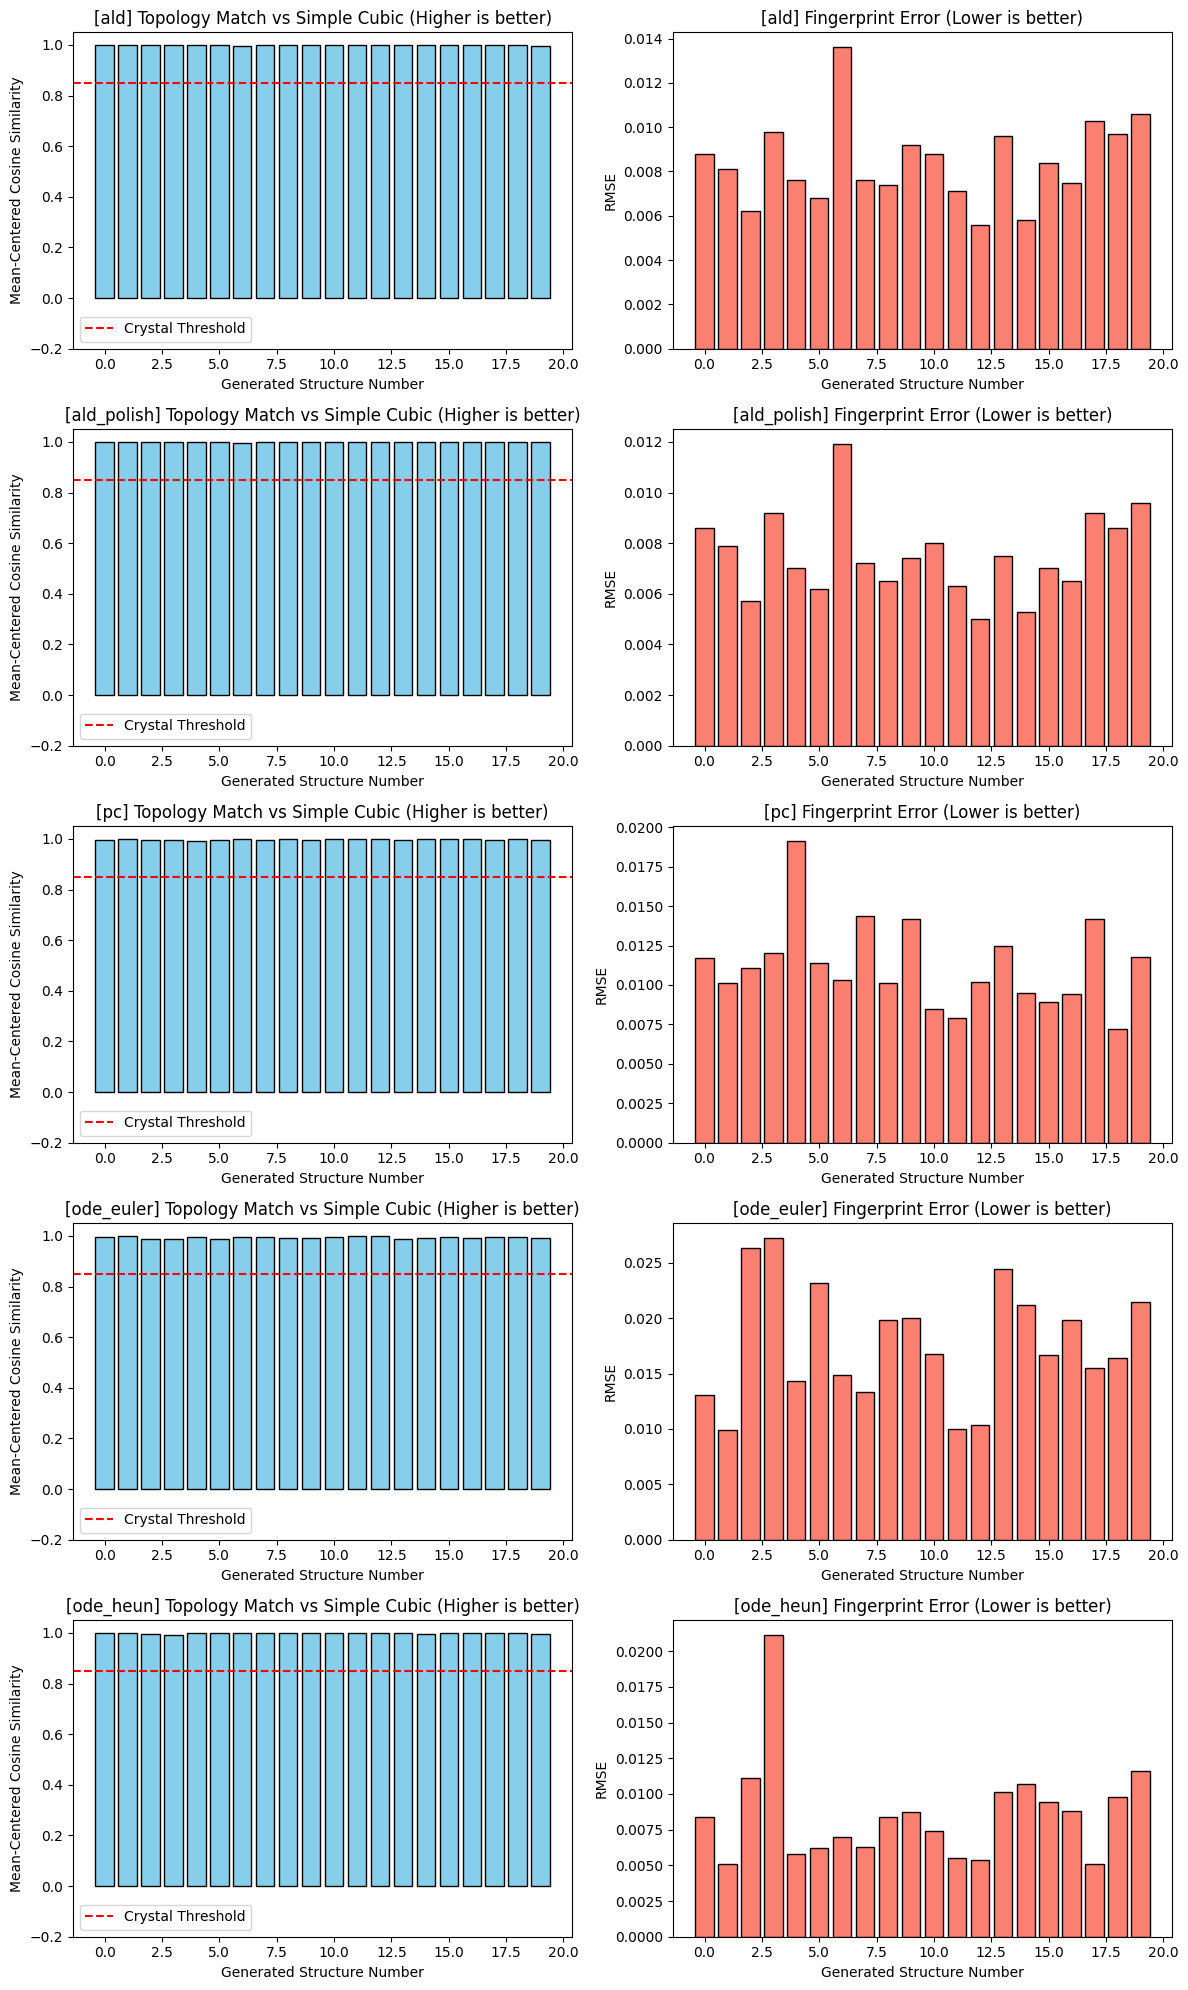


DONE.


In [ ]:

# ACE similarity check, per sampler, vs simple-cubic reference (POSCAR_00001)

from atomic_recipes.descriptors.ace import ACELayer
t_ace = time.time()
ace = ACELayer(n_limits=[2, 2, 2], l_limits=[2, 2, 2]).to(device)

def ace_fp(atoms_list):
    """Calculates the Atomic Cluster Expansion fingerprint for a list of ASE Atoms."""
    mats = [Material(direct_positions=torch.tensor(a.get_scaled_positions()).float(),
                     atom_numbers=torch.tensor(a.numbers),
                     lattice_vectors=torch.tensor(a.get_cell().array).float())
            for a in atoms_list]
    with torch.no_grad():
        B, _, _ = ace(MaterialsDataset(mats))
    return B.mean(dim=1).cpu().numpy()

# 1. Load reference (simple cubic, POSCAR_00001) once
ref_atoms = ase_io.read(REF_PATH, format="vasp")

# Reuse gen_paths_by_sampler from the generation cell (pc / ode_euler / ode_heun)
SAMPLER_NAMES = list(gen_paths_by_sampler.keys())

# 2. Load ALL generated structures across all samplers in one batch, alongside the reference,
#    so the ACE fingerprints are computed in a single consistent pass
all_atoms = [ref_atoms]
sampler_of_index = []   # tracks which sampler each fingerprint (after the ref) belongs to
for sampler_name in SAMPLER_NAMES:
    for p in gen_paths_by_sampler[sampler_name]:
        all_atoms.append(ase_io.read(p, format="vasp"))
        sampler_of_index.append(sampler_name)

fps = ace_fp(all_atoms)

# 3. Extract and prepare the reference fingerprint
fp_ref = fps[0]
rf_centered = fp_ref - np.mean(fp_ref)
rf_norm_centered = rf_centered / (np.linalg.norm(rf_centered) + 1e-12)
rf_raw_norm = fp_ref / (np.linalg.norm(fp_ref) + 1e-12)

# 4. Compute metrics for every generated structure, tagged by sampler
rows = []
for sampler_name, f in zip(sampler_of_index, fps[1:]):
    f_centered = f - np.mean(f)
    f_norm_centered = f_centered / (np.linalg.norm(f_centered) + 1e-12)
    sim_centered = float(np.dot(rf_norm_centered, f_norm_centered))

    f_raw_norm = f / (np.linalg.norm(f) + 1e-12)
    rmse = float(np.sqrt(np.mean((rf_raw_norm - f_raw_norm) ** 2)))

    rows.append({
        "sampler": sampler_name,
        "ace_similarity_centered": round(sim_centered, 4),
        "ace_rmse": round(rmse, 4),
    })

df_ace = pd.DataFrame(rows)
# structure index within each sampler, for readability
df_ace["structure"] = df_ace.groupby("sampler").cumcount()
df_ace = df_ace[["sampler", "structure", "ace_similarity_centered", "ace_rmse"]]

out_csv = f"{GEN_DIR}/v4i3_ace_similarity_per_sampler.csv"
df_ace.to_csv(out_csv, index=False)

print(f"[ace] Rigorous evaluation finished in {time.time()-t_ace:.2f}s")
print(f"[ace] Saved per-structure results -> {out_csv}\n")

# 5. Per-sampler summary
summary_ace = df_ace.groupby("sampler").agg(
    mean_similarity=("ace_similarity_centered", "mean"),
    mean_rmse=("ace_rmse", "mean"),
    n_above_threshold=("ace_similarity_centered", lambda s: int((s >= 0.85).sum())),
    n_total=("ace_similarity_centered", "size"),
).reindex(SAMPLER_NAMES)
print("=== ACE similarity to simple-cubic reference, per sampler ===")
print(summary_ace.to_string())

# 6. Plots: one row per sampler, similarity + RMSE side by side
n_samplers = len(SAMPLER_NAMES)
fig, axes = plt.subplots(n_samplers, 2, figsize=(12, 4 * n_samplers))
if n_samplers == 1:
    axes = axes.reshape(1, 2)

for row_i, sampler_name in enumerate(SAMPLER_NAMES):
    sub = df_ace[df_ace["sampler"] == sampler_name]

    ax1 = axes[row_i, 0]
    ax1.bar(sub["structure"], sub["ace_similarity_centered"], color='skyblue', edgecolor='black')
    ax1.set_xlabel("Generated Structure Number")
    ax1.set_ylabel("Mean-Centered Cosine Similarity")
    ax1.set_title(f"[{sampler_name}] Topology Match vs Simple Cubic (Higher is better)")
    ax1.set_ylim(-0.2, 1.05)
    ax1.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, label="Crystal Threshold")
    ax1.legend()

    ax2 = axes[row_i, 1]
    ax2.bar(sub["structure"], sub["ace_rmse"], color='salmon', edgecolor='black')
    ax2.set_xlabel("Generated Structure Number")
    ax2.set_ylabel("RMSE")
    ax2.set_title(f"[{sampler_name}] Fingerprint Error (Lower is better)")

plt.tight_layout()
plt.savefig(f"{GEN_DIR}/v4i3_ace_similarity_per_sampler.png", dpi=150)
plt.show()

print("\nDONE.")

In [ ]:
import os, time, itertools
import numpy as np
import pandas as pd
import torch
from ase import io as ase_io, Atoms

os.makedirs(GEN_DIR, exist_ok=True)

ref_structure = ase_io.read(REF_PATH, format="vasp")
ref_mat = Material(
    direct_positions=torch.tensor(ref_structure.get_scaled_positions()).float(),
    atom_numbers=torch.tensor(ref_structure.numbers),
    lattice_vectors=torch.tensor(ref_structure.get_cell().array).float()
)
mds_ref = MaterialsDataset([ref_mat])
graph_ref = MaterialGraph(mds_ref, cutoff=CUTOFF, use_niggli=True, noise_params=None)
template = graph_ref[0]
if template.lattice_vectors.dim() == 1:
    template.lattice_vectors = template.lattice_vectors.unsqueeze(0)

inv = {int(v): int(k) for k, v in atom_types.items()}
lat3_t = _niggli_to_reduced(template.lattice_vectors).to(device)
lat3 = lat3_t.cpu().numpy()
inv_lat3_t = torch.linalg.inv(lat3_t)


# Shared hyperparameters

N_SIGMAS_GEN    = 100
INNER_STEPS     = 100     # used by ald / ald_polish
POLISH_STEPS    = 400     # used by ald_polish
CORRECTOR_STEPS = 15       # used by pc
N_GEN           = 20
EPSILON         = 5e-5
FLOOR           = 2.2

sigmas = torch.tensor(np.geomspace(NOISE["sigma_end"], NOISE["sigma_start"], N_SIGMAS_GEN),
                      dtype=torch.float32, device=device)
sigma_L = sigmas[-1]
print("sigmas Å (high->low):", sigmas.cpu().numpy().round(4))

def update_edge_attr(g, lat3_t):
    row, col = g.edge_index
    dfrac = g.pos[row] - g.pos[col]; dfrac = dfrac - dfrac.round()
    g.edge_attr = (dfrac @ lat3_t).norm(dim=-1, keepdim=True)
    return g

def get_score(g, z, sigma):
    """Returns true_scores = ∇_x log p_sigma(x) in Cartesian Å units."""
    g.sigma = sigma.view(1).to(device)
    g = update_edge_attr(g, lat3_t)
    scores, _ = score_dec(g, z)
    return scores / sigma

def apply_cart_update(g, cart_update):
    frac_update = cart_update @ inv_lat3_t
    g.pos = torch.remainder(g.pos + frac_update, 1.0)
    return g

def min_and_nn_distance(frac, cell):
    frac = torch.as_tensor(frac, dtype=torch.float64)
    cell = torch.as_tensor(cell, dtype=torch.float64)
    shifts = torch.tensor(list(itertools.product([-1,0,1], repeat=3)), dtype=torch.float64)
    N = frac.shape[0]
    d = (frac[:,None,:] - frac[None,:,:])[:,:,None,:] + shifts[None,None,:,:]
    dist = (d @ cell).norm(dim=-1)
    eye = torch.eye(N, dtype=torch.bool); zero = (shifts.abs().sum(1) == 0)
    dist[eye[:,:,None] & zero[None,None,:]] = float("inf")
    pm = dist.amin(dim=2)
    return pm.min().item(), pm.min(dim=1).values.median().item()


# Method 1 & 2: Annealed Langevin Dynamics (+ optional polish)

def run_ald(g, z, polish):
    for sigma_j in sigmas:
        alpha_j = (EPSILON * (sigma_j**2) / (sigma_L**2)).item()
        for _ in range(INNER_STEPS):
            true_scores = get_score(g, z, sigma_j)
            noise = torch.randn_like(g.pos)
            cart_update = alpha_j * true_scores + (2 * alpha_j)**0.5 * noise
            g = apply_cart_update(g, cart_update)

    if polish:
        alpha_L = EPSILON
        for _ in range(POLISH_STEPS):
            true_scores = get_score(g, z, sigma_L)
            cart_update = alpha_L * true_scores   # no noise term
            g = apply_cart_update(g, cart_update)
    return g


# Method 3: Predictor-Corrector (Song et al. 2021, VE-SDE)

def run_pc(g, z):
    for i in range(len(sigmas) - 1):
        sigma_i, sigma_next = sigmas[i], sigmas[i + 1]

        # Predictor: reverse-time SDE step
        true_scores = get_score(g, z, sigma_i)
        diff = sigma_i**2 - sigma_next**2
        noise = torch.randn_like(g.pos)
        cart_update = diff * true_scores + torch.sqrt(diff) * noise
        g = apply_cart_update(g, cart_update)

        # Corrector: a few Langevin steps at the new noise level
        alpha_c = (EPSILON * (sigma_next**2) / (sigma_L**2)).item()
        for _ in range(CORRECTOR_STEPS):
            true_scores = get_score(g, z, sigma_next)
            noise = torch.randn_like(g.pos)
            cart_update = alpha_c * true_scores + (2 * alpha_c)**0.5 * noise
            g = apply_cart_update(g, cart_update)
    return g


# Method 4: Probability Flow ODE, Euler (deterministic)

def run_ode_euler(g, z):
    for i in range(len(sigmas) - 1):
        sigma_i, sigma_next = sigmas[i], sigmas[i + 1]
        true_scores = get_score(g, z, sigma_i)
        d = -sigma_i * true_scores
        cart_update = (sigma_next - sigma_i) * d
        g = apply_cart_update(g, cart_update)
    return g


# Method 5: Probability Flow ODE, Heun (2nd order, Karras et al. 2022)

def run_ode_heun(g, z):
    for i in range(len(sigmas) - 1):
        sigma_i, sigma_next = sigmas[i], sigmas[i + 1]

        true_scores_i = get_score(g, z, sigma_i)
        d_i = -sigma_i * true_scores_i
        cart_euler = (sigma_next - sigma_i) * d_i
        g_euler = apply_cart_update(g, cart_euler)

        true_scores_next = get_score(g_euler, z, sigma_next)
        d_next = -sigma_next * true_scores_next
        cart_update = (sigma_next - sigma_i) * 0.5 * (d_i + d_next)
        g = apply_cart_update(g, cart_update)
    return g

SAMPLERS = {

    "pc":         run_pc,
    "ode_euler":  run_ode_euler,
    "ode_heun":   run_ode_heun,
}


# Run ALL samplers, one batch of N_GEN structures each

encoder.eval(); aggregator.eval(); score_dec.eval()

all_rows = []
gen_paths_by_sampler = {}

for sampler_name, sampler_fn in SAMPLERS.items():
    sampler_dir = f"{GEN_DIR}/{sampler_name}"
    os.makedirs(sampler_dir, exist_ok=True)

    torch.manual_seed(0)   # same seed/z's across samplers for a fair comparison
    t_gen = time.time()
    gen_paths = []

    for k in tqdm(range(N_GEN),desc=f"{sampler_name:12s}",unit="structure"):
        g = template.clone().to(device)
        g.pos = torch.rand_like(g.pos)
        g.batch = torch.zeros(g.pos.shape[0], dtype=torch.long, device=device)
        g.num_graphs = 1
        if g.lattice_vectors.dim() == 1:
            g.lattice_vectors = g.lattice_vectors.unsqueeze(0)

        z = torch.randn(1, LATENT, device=device)
        with torch.no_grad():
            g = sampler_fn(g, z)

        frac = g.pos.cpu().numpy()
        znums = [inv[int(c)] for c in template.x.argmax(1).tolist()]

        atoms = Atoms(numbers=znums, scaled_positions=frac, cell=lat3, pbc=True)
        p = f"{sampler_dir}/POSCAR_gen_{k:03d}"
        ase_io.write(p, atoms, format="vasp")
        gen_paths.append(p)

        md, nn = min_and_nn_distance(frac, lat3)
        all_rows.append({
            "sampler": sampler_name,
            "structure": k,
            "min_dist_A": round(md, 3),
            "nn_median_A": round(nn, 3),
            "passes_floor": md >= FLOOR,
            "nn_in_window": WIN[0] <= nn <= WIN[1],
        })

    gen_paths_by_sampler[sampler_name] = gen_paths
    elapsed = time.time() - t_gen
    n_pass = sum(1 for r in all_rows if r["sampler"] == sampler_name and r["passes_floor"])
    n_win  = sum(1 for r in all_rows if r["sampler"] == sampler_name and r["nn_in_window"])
    print(f"[{sampler_name:12s}] {len(gen_paths)} structures in {elapsed:6.1f}s -> {sampler_dir} "
          f"| floor {n_pass}/{N_GEN} | window {n_win}/{N_GEN}")


# Combined comparison table

df_all = pd.DataFrame(all_rows)
df_all.to_csv("/kaggle/working/v4i3_bondlength_filter_all_samplers.csv", index=False)

summary = df_all.groupby("sampler").agg(
    pass_floor=("passes_floor", "sum"),
    in_window=("nn_in_window", "sum"),
    mean_min_dist=("min_dist_A", "mean"),
).reindex(SAMPLERS.keys())
print("\n=== Summary across samplers (out of", N_GEN, "structures each) ===")
print(summary.to_string())

sigmas Å (high->low): [3.     2.872  2.7494 2.6321 2.5198 2.4122 2.3093 2.2108 2.1164 2.0261
 1.9396 1.8569 1.7776 1.7018 1.6292 1.5596 1.4931 1.4294 1.3684 1.31
 1.2541 1.2006 1.1493 1.1003 1.0533 1.0084 0.9653 0.9241 0.8847 0.847
 0.8108 0.7762 0.7431 0.7114 0.681  0.652  0.6241 0.5975 0.572  0.5476
 0.5242 0.5019 0.4804 0.4599 0.4403 0.4215 0.4035 0.3863 0.3698 0.354
 0.3389 0.3245 0.3106 0.2974 0.2847 0.2725 0.2609 0.2498 0.2391 0.2289
 0.2191 0.2098 0.2008 0.1923 0.1841 0.1762 0.1687 0.1615 0.1546 0.148
 0.1417 0.1356 0.1298 0.1243 0.119  0.1139 0.1091 0.1044 0.1    0.0957
 0.0916 0.0877 0.084  0.0804 0.0769 0.0737 0.0705 0.0675 0.0646 0.0619
 0.0592 0.0567 0.0543 0.052  0.0497 0.0476 0.0456 0.0436 0.0418 0.04  ]


pc          :   0%|          | 0/20 [00:00<?, ?structure/s]

[pc          ] 20 structures in   99.6s -> /kaggle/working/Generated_V4i3/pc | floor 8/20 | window 20/20


ode_euler   :   0%|          | 0/20 [00:00<?, ?structure/s]

[ode_euler   ] 20 structures in    6.3s -> /kaggle/working/Generated_V4i3/ode_euler | floor 0/20 | window 20/20


ode_heun    :   0%|          | 0/20 [00:00<?, ?structure/s]

[ode_heun    ] 20 structures in   12.7s -> /kaggle/working/Generated_V4i3/ode_heun | floor 4/20 | window 20/20

=== Summary across samplers (out of 20 structures each) ===
           pass_floor  in_window  mean_min_dist
sampler                                        
pc                  8         20        2.16075
ode_euler           0         20        1.39480
ode_heun            4         20        1.95475


In [ ]:
import shutil
import os

# Check where your generated files are
print("Generated folder:", GEN_DIR)
print("Contents:", os.listdir(GEN_DIR))

# Create a ZIP file
zip_path = shutil.make_archive(
    "/kaggle/working/generated_poscars",
    "zip",
    GEN_DIR
)

print(f"ZIP created successfully: {zip_path}")

Generated folder: /kaggle/working/Generated_V4i3
Contents: ['ode_euler', 'ald', 'pc', 'ode_heun', 'ald_polish']
ZIP created successfully: /kaggle/working/generated_poscars.zip


[ace] Rigorous evaluation finished in 0.17s
[ace] Saved per-structure results -> /kaggle/working/Generated_V4i3/v4i3_ace_similarity_per_sampler.csv

=== ACE similarity to simple-cubic reference, per sampler ===
           mean_similarity  mean_rmse  n_above_threshold  n_total
sampler                                                          
pc                0.999150   0.006600                 20       20
ode_euler         0.994005   0.017235                 20       20
ode_heun          0.998465   0.008415                 20       20


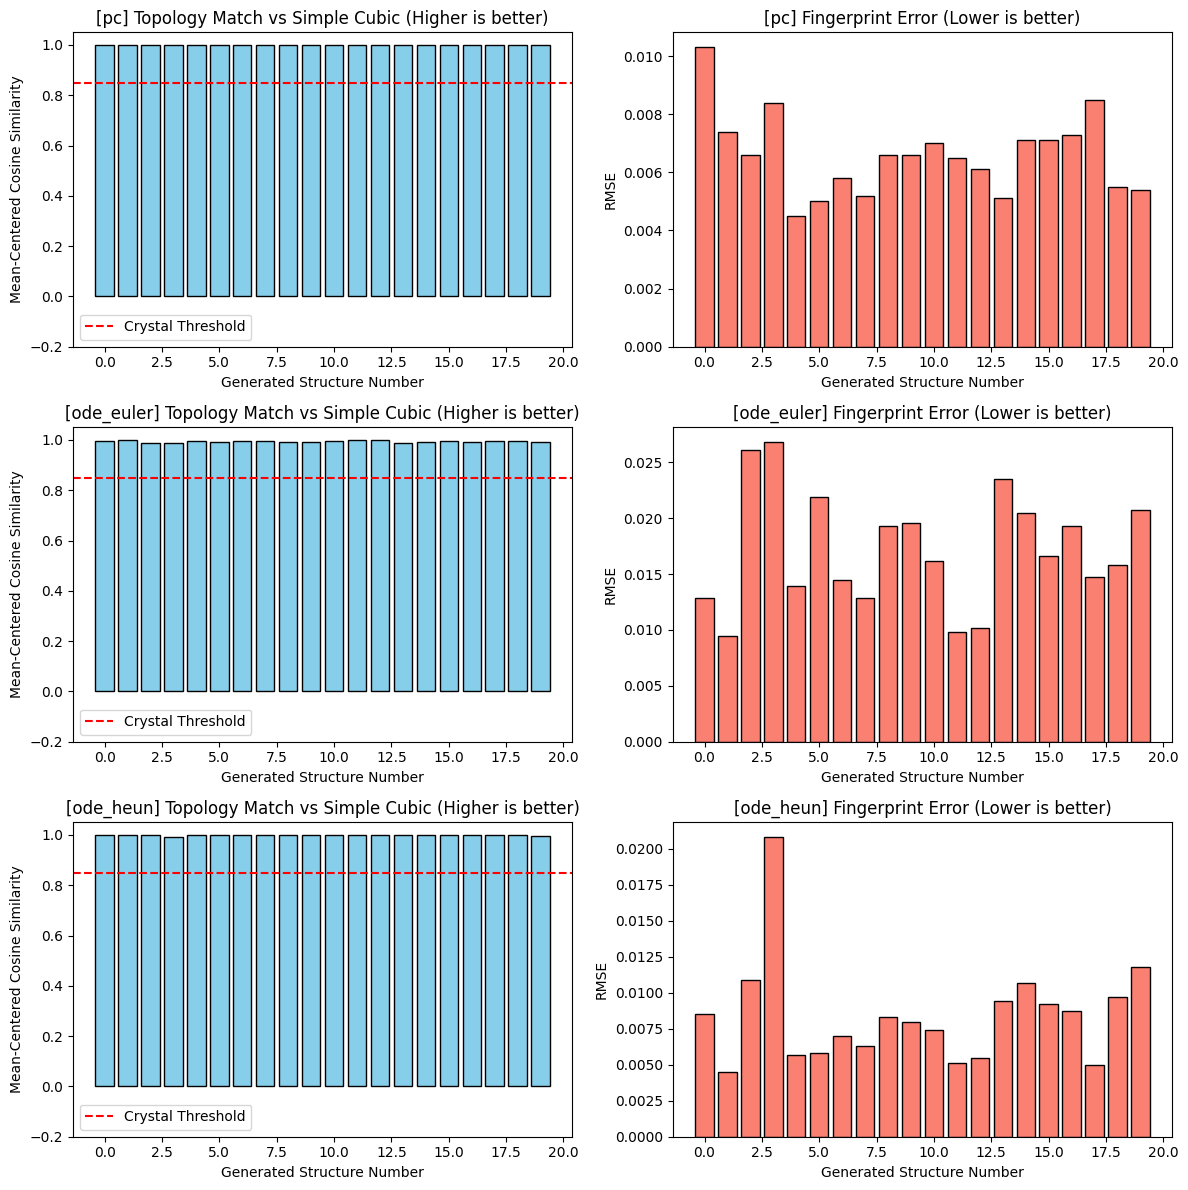


DONE.


In [ ]:

# ACE similarity check, per sampler, vs simple-cubic reference (POSCAR_00001)

from atomic_recipes.descriptors.ace import ACELayer
t_ace = time.time()
ace = ACELayer(n_limits=[2, 2, 2], l_limits=[2, 2, 2]).to(device)

def ace_fp(atoms_list):
    """Calculates the Atomic Cluster Expansion fingerprint for a list of ASE Atoms."""
    mats = [Material(direct_positions=torch.tensor(a.get_scaled_positions()).float(),
                     atom_numbers=torch.tensor(a.numbers),
                     lattice_vectors=torch.tensor(a.get_cell().array).float())
            for a in atoms_list]
    with torch.no_grad():
        B, _, _ = ace(MaterialsDataset(mats))
    return B.mean(dim=1).cpu().numpy()

# 1. Load reference (simple cubic, POSCAR_00001) once
ref_atoms = ase_io.read(REF_PATH, format="vasp")

# Reuse gen_paths_by_sampler from the generation cell (pc / ode_euler / ode_heun)
SAMPLER_NAMES = list(gen_paths_by_sampler.keys())

# 2. Load ALL generated structures across all samplers in one batch, alongside the reference,
#    so the ACE fingerprints are computed in a single consistent pass
all_atoms = [ref_atoms]
sampler_of_index = []   # tracks which sampler each fingerprint (after the ref) belongs to
for sampler_name in SAMPLER_NAMES:
    for p in gen_paths_by_sampler[sampler_name]:
        all_atoms.append(ase_io.read(p, format="vasp"))
        sampler_of_index.append(sampler_name)

fps = ace_fp(all_atoms)

# 3. Extract and prepare the reference fingerprint
fp_ref = fps[0]
rf_centered = fp_ref - np.mean(fp_ref)
rf_norm_centered = rf_centered / (np.linalg.norm(rf_centered) + 1e-12)
rf_raw_norm = fp_ref / (np.linalg.norm(fp_ref) + 1e-12)

# 4. Compute metrics for every generated structure, tagged by sampler
rows = []
for sampler_name, f in zip(sampler_of_index, fps[1:]):
    f_centered = f - np.mean(f)
    f_norm_centered = f_centered / (np.linalg.norm(f_centered) + 1e-12)
    sim_centered = float(np.dot(rf_norm_centered, f_norm_centered))

    f_raw_norm = f / (np.linalg.norm(f) + 1e-12)
    rmse = float(np.sqrt(np.mean((rf_raw_norm - f_raw_norm) ** 2)))

    rows.append({
        "sampler": sampler_name,
        "ace_similarity_centered": round(sim_centered, 4),
        "ace_rmse": round(rmse, 4),
    })

df_ace = pd.DataFrame(rows)
# structure index within each sampler, for readability
df_ace["structure"] = df_ace.groupby("sampler").cumcount()
df_ace = df_ace[["sampler", "structure", "ace_similarity_centered", "ace_rmse"]]

out_csv = f"{GEN_DIR}/v4i3_ace_similarity_per_sampler.csv"
df_ace.to_csv(out_csv, index=False)

print(f"[ace] Rigorous evaluation finished in {time.time()-t_ace:.2f}s")
print(f"[ace] Saved per-structure results -> {out_csv}\n")

# 5. Per-sampler summary
summary_ace = df_ace.groupby("sampler").agg(
    mean_similarity=("ace_similarity_centered", "mean"),
    mean_rmse=("ace_rmse", "mean"),
    n_above_threshold=("ace_similarity_centered", lambda s: int((s >= 0.85).sum())),
    n_total=("ace_similarity_centered", "size"),
).reindex(SAMPLER_NAMES)
print("=== ACE similarity to simple-cubic reference, per sampler ===")
print(summary_ace.to_string())

# 6. Plots: one row per sampler, similarity + RMSE side by side
n_samplers = len(SAMPLER_NAMES)
fig, axes = plt.subplots(n_samplers, 2, figsize=(12, 4 * n_samplers))
if n_samplers == 1:
    axes = axes.reshape(1, 2)

for row_i, sampler_name in enumerate(SAMPLER_NAMES):
    sub = df_ace[df_ace["sampler"] == sampler_name]

    ax1 = axes[row_i, 0]
    ax1.bar(sub["structure"], sub["ace_similarity_centered"], color='skyblue', edgecolor='black')
    ax1.set_xlabel("Generated Structure Number")
    ax1.set_ylabel("Mean-Centered Cosine Similarity")
    ax1.set_title(f"[{sampler_name}] Topology Match vs Simple Cubic (Higher is better)")
    ax1.set_ylim(-0.2, 1.05)
    ax1.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, label="Crystal Threshold")
    ax1.legend()

    ax2 = axes[row_i, 1]
    ax2.bar(sub["structure"], sub["ace_rmse"], color='salmon', edgecolor='black')
    ax2.set_xlabel("Generated Structure Number")
    ax2.set_ylabel("RMSE")
    ax2.set_title(f"[{sampler_name}] Fingerprint Error (Lower is better)")

plt.tight_layout()
plt.savefig(f"{GEN_DIR}/v4i3_ace_similarity_per_sampler.png", dpi=150)
plt.show()

print("\nDONE.")

In [ ]:
!pip install mace-torch -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 3.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 20.1 MB/s eta 0:00:00


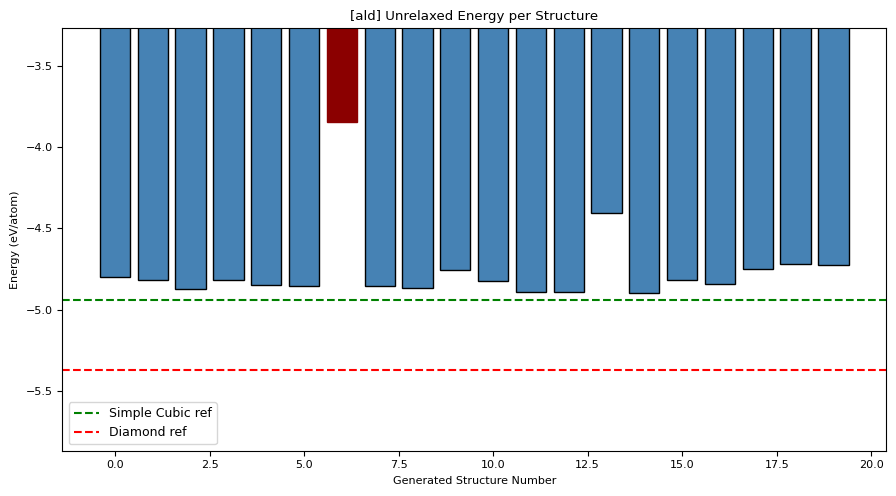

Saved -> /kaggle/working/Generated_V4i3/v4i3_energy_ald.png


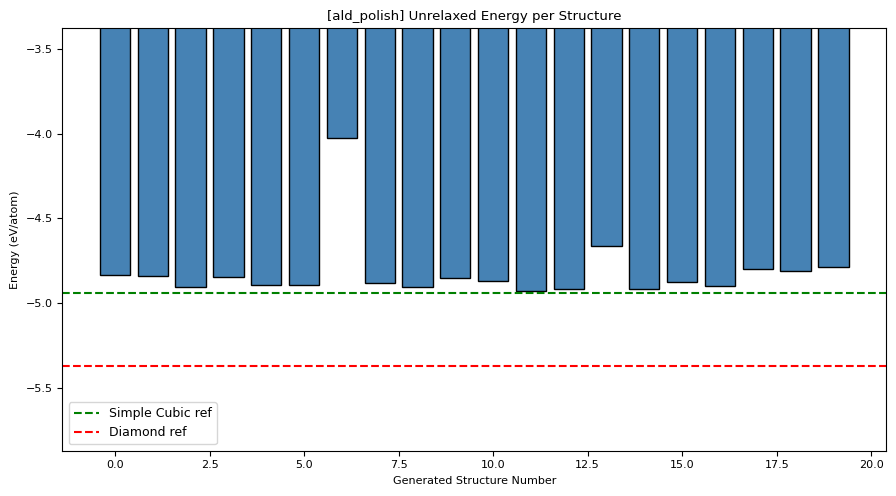

Saved -> /kaggle/working/Generated_V4i3/v4i3_energy_ald_polish.png


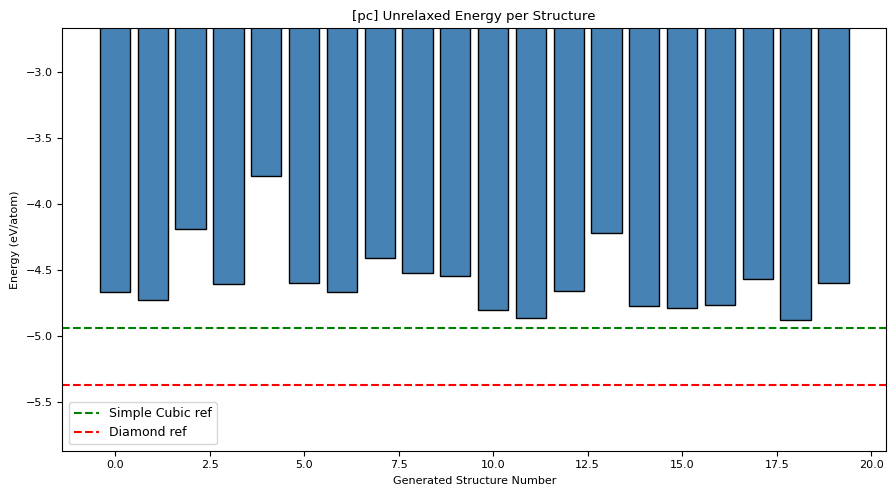

Saved -> /kaggle/working/Generated_V4i3/v4i3_energy_pc.png


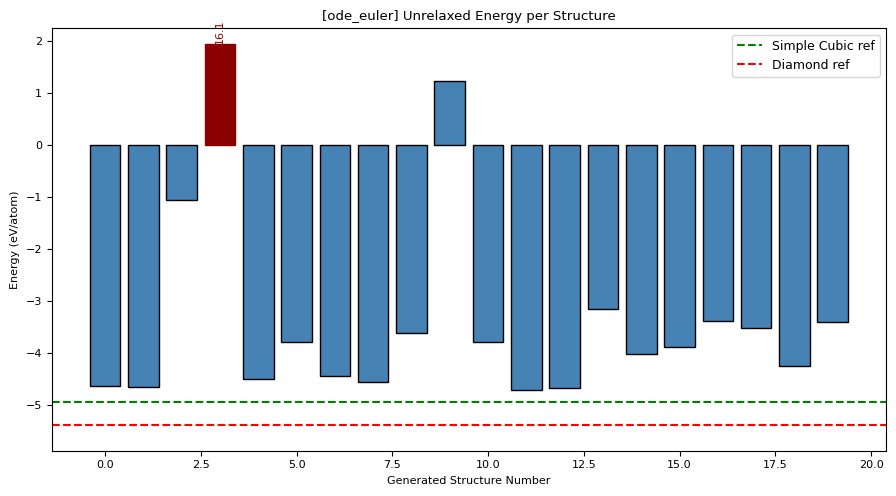

Saved -> /kaggle/working/Generated_V4i3/v4i3_energy_ode_euler.png


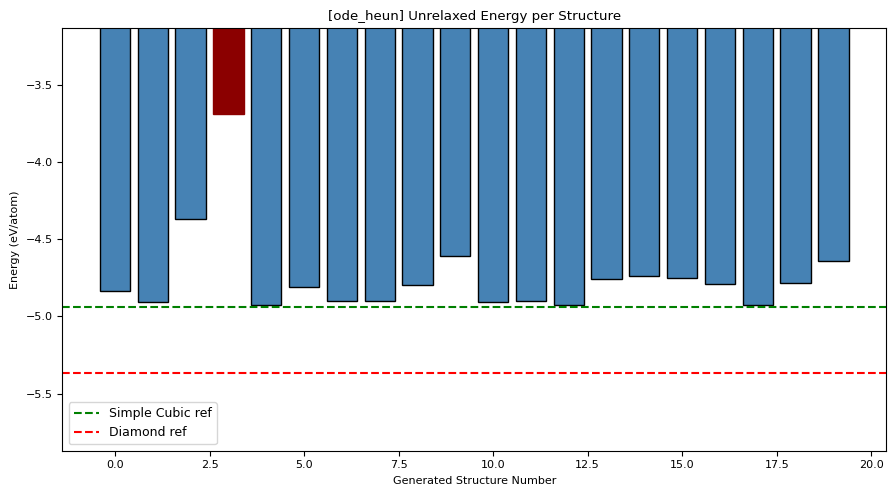

Saved -> /kaggle/working/Generated_V4i3/v4i3_energy_ode_heun.png

DONE.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def capped_values_and_labels(values, cap):
    values = np.asarray(values, dtype=float)
    clipped = values > cap
    plot_vals = np.where(clipped, cap, values)
    return plot_vals, clipped

for sampler_name in SAMPLER_NAMES:
    sub = df_energy[df_energy["sampler"] == sampler_name].sort_values("structure")
    vals = sub["energy_eV_per_atom"].values
    finite_vals = vals[np.isfinite(vals)]
    if len(finite_vals) == 0:
        continue

    p90 = np.nanpercentile(finite_vals, 90)
    cap = p90 + 0.5 * abs(p90 - dia_energy) + 0.5

    plot_vals, clipped = capped_values_and_labels(vals, cap)

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(sub["structure"], plot_vals, color="steelblue", edgecolor="black")

    for x, real_v, is_clip, bar in zip(sub["structure"], vals, clipped, bars):
        if is_clip:
            bar.set_color("darkred")
            ax.text(x, cap, f"{real_v:.1f}", ha="center", va="bottom",
                     fontsize=8, rotation=90, color="darkred")

    ax.axhline(y=sc_energy, color="green", linestyle="--", linewidth=1.5, label="Simple Cubic ref")
    ax.axhline(y=dia_energy, color="red", linestyle="--", linewidth=1.5, label="Diamond ref")
    ax.set_xlabel("Generated Structure Number")
    ax.set_ylabel("Energy (eV/atom)")
    ax.set_title(f"[{sampler_name}] Unrelaxed Energy per Structure")
    ax.set_ylim(min(finite_vals.min(), dia_energy) - 0.5, cap * 1.15 if cap > 0 else cap * 0.85)
    ax.legend(fontsize=9)

    plt.tight_layout()
    out_path = f"{GEN_DIR}/v4i3_energy_{sampler_name}.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved -> {out_path}")

print("\nDONE.")

In [ ]:
import os, itertools
import torch
import pandas as pd
from ase import io as ase_io


# Sanity check: bond-length

FLOOR = 2.0
WIN = [2.0, 2.6]
SAMPLER_NAMES = list(gen_paths_by_sampler.keys())

def min_and_nn_distance(frac, cell):
    frac = torch.as_tensor(frac, dtype=torch.float64)
    cell = torch.as_tensor(cell, dtype=torch.float64)
    shifts = torch.tensor(list(itertools.product([-1, 0, 1], repeat=3)), dtype=torch.float64)
    N = frac.shape[0]
    d = (frac[:, None, :] - frac[None, :, :])[:, :, None, :] + shifts[None, None, :, :]
    dist = (d @ cell).norm(dim=-1)
    eye = torch.eye(N, dtype=torch.bool)
    zero = (shifts.abs().sum(1) == 0)
    dist[eye[:, :, None] & zero[None, None, :]] = float("inf")
    pm = dist.amin(dim=2)
    return pm.min().item(), pm.min(dim=1).values.median().item()

all_rows = []

for sampler_name in SAMPLER_NAMES:
    paths = gen_paths_by_sampler[sampler_name]
    valid_count = 0
    print(f"\nAnalyzing Generated (unrelaxed) Structures for [{sampler_name}]...")

    for k, p in enumerate(paths):
        if os.path.exists(p):
            atoms = ase_io.read(p, format="vasp")
            frac = atoms.get_scaled_positions()
            cell = atoms.get_cell().array

            md, nn = min_and_nn_distance(frac, cell)

            all_rows.append({
                "sampler": sampler_name,
                "structure": k,
                "min_dist_A": round(md, 3),
                "nn_median_A": round(nn, 3),
                "passes_floor": md >= FLOOR,
                "nn_in_window": WIN[0] <= nn <= WIN[1],
            })
            valid_count += 1

    if valid_count > 0:
        sub = [r for r in all_rows if r["sampler"] == sampler_name]
        n_pass = sum(1 for r in sub if r["passes_floor"])
        n_win = sum(1 for r in sub if r["nn_in_window"])
        print(f"  Bond-length filter (floor={FLOOR} A, Si window={WIN[0]}-{WIN[1]} A)")
        print(f"  Passed overlap floor: {n_pass}/{valid_count}  |  NN in Si window: {n_win}/{valid_count}")
    else:
        print(f"  No structures found for {sampler_name}")

# ============================================================
# Separate table per sampler (own DataFrame, own headline, own CSV)
# ============================================================
from IPython.display import display, Markdown

df_by_sampler = {}

if all_rows:
    df_gen_all = pd.DataFrame(all_rows)

    for sampler_name in SAMPLER_NAMES:
        df_s = df_gen_all[df_gen_all["sampler"] == sampler_name].drop(columns="sampler").reset_index(drop=True)
        df_by_sampler[sampler_name] = df_s

        out_csv = f"/kaggle/working/v4i3_bondlength_filter_{sampler_name}_unrelaxed.csv"
        df_s.to_csv(out_csv, index=False)

        n_pass = int(df_s["passes_floor"].sum())
        n_win = int(df_s["nn_in_window"].sum())
        n_valid = len(df_s)

        display(Markdown(
            f"### Sanity check — `{sampler_name}`\n"
            f"Bond-length filter (floor={FLOOR} Å, Si window={WIN[0]}-{WIN[1]} Å)  \n"
            f"**Passed overlap floor: {n_pass}/{n_valid}  |  NN in Si window: {n_win}/{n_valid}**"
        ))
        display(df_s)

    # quick side-by-side summary across all samplers, purely for convenience
    summary_gen = df_gen_all.groupby("sampler").agg(
        pass_floor=("passes_floor", "sum"),
        in_window=("nn_in_window", "sum"),
        n_valid=("structure", "count"),
        mean_min_dist=("min_dist_A", "mean"),
        mean_nn_median=("nn_median_A", "mean"),
    ).reindex(SAMPLER_NAMES)
    display(Markdown("### Summary across all samplers (for reference)"))
    display(summary_gen)
else:
    print("No structures found for any sampler.")


Analyzing Generated (unrelaxed) Structures for [ald]...
  Bond-length filter (floor=2.0 A, Si window=2.0-2.6 A)
  Passed overlap floor: 15/20  |  NN in Si window: 20/20

Analyzing Generated (unrelaxed) Structures for [ald_polish]...
  Bond-length filter (floor=2.0 A, Si window=2.0-2.6 A)
  Passed overlap floor: 17/20  |  NN in Si window: 20/20

Analyzing Generated (unrelaxed) Structures for [pc]...
  Bond-length filter (floor=2.0 A, Si window=2.0-2.6 A)
  Passed overlap floor: 7/20  |  NN in Si window: 20/20

Analyzing Generated (unrelaxed) Structures for [ode_euler]...
  Bond-length filter (floor=2.0 A, Si window=2.0-2.6 A)
  Passed overlap floor: 0/20  |  NN in Si window: 20/20

Analyzing Generated (unrelaxed) Structures for [ode_heun]...
  Bond-length filter (floor=2.0 A, Si window=2.0-2.6 A)
  Passed overlap floor: 10/20  |  NN in Si window: 20/20


### Sanity check — `ald`
Bond-length filter (floor=2.0 Å, Si window=2.0-2.6 Å)  
**Passed overlap floor: 15/20  |  NN in Si window: 20/20**

,structure,min_dist_A,nn_median_A,passes_floor,nn_in_window
0,0,2.136,2.281,True,True
1,1,1.857,2.372,False,True
2,2,2.184,2.402,True,True
3,3,2.247,2.323,True,True
4,4,2.121,2.358,True,True
5,5,2.125,2.301,True,True
6,6,1.137,2.264,False,True
7,7,2.160,2.386,True,True
8,8,2.236,2.357,True,True
9,9,2.007,2.214,True,True


### Sanity check — `ald_polish`
Bond-length filter (floor=2.0 Å, Si window=2.0-2.6 Å)  
**Passed overlap floor: 17/20  |  NN in Si window: 20/20**

,structure,min_dist_A,nn_median_A,passes_floor,nn_in_window
0,0,2.273,2.352,True,True
1,1,1.885,2.425,False,True
2,2,2.271,2.415,True,True
3,3,2.239,2.368,True,True
4,4,2.208,2.402,True,True
5,5,2.249,2.383,True,True
6,6,1.267,2.290,False,True
7,7,2.321,2.424,True,True
8,8,2.267,2.404,True,True
9,9,2.073,2.266,True,True


...

,structure,min_dist_A,nn_median_A,passes_floor,nn_in_window
0,0,1.914,2.237,False,True
1,1,1.888,2.222,False,True
2,2,0.594,2.090,False,True
3,3,0.436,2.119,False,True
4,4,1.640,2.187,False,True
5,5,1.610,2.132,False,True
6,6,1.616,2.165,False,True
7,7,1.761,2.222,False,True
8,8,1.062,2.218,False,True
9,9,0.502,2.211,False,True


### Sanity check — `ode_heun`
Bond-length filter (floor=2.0 Å, Si window=2.0-2.6 Å)  
**Passed overlap floor: 10/20  |  NN in Si window: 20/20**

,structure,min_dist_A,nn_median_A,passes_floor,nn_in_window
0,0,2.275,2.337,True,True
1,1,1.957,2.438,False,True
2,2,1.578,2.216,False,True
3,3,0.577,2.314,False,True
4,4,2.271,2.369,True,True
5,5,2.125,2.327,True,True
6,6,2.158,2.292,True,True
7,7,2.046,2.312,True,True
8,8,2.136,2.325,True,True
9,9,1.616,2.347,False,True


### Summary across all samplers (for reference)

,pass_floor,in_window,n_valid,mean_min_dist,mean_nn_median
sampler,,,,,
ald,15,20,20,2.02980,2.32370
ald_polish,17,20,20,2.13420,2.37265
pc,7,20,20,1.84730,2.23920
ode_euler,0,20,20,1.36375,2.18480
ode_heun,10,20,20,1.93310,2.32970
